# Semi-Supervised CIFAR-10 — SimCLR自己教師あり事前学習 + 半教師あり学習 (scratch実装)

> **前研究(CIFAR-100/CIFAR-10 v20)の反省を受けた、新しい実験系列。**
> v20では CLIP zero-shot が 92.93% を出し、labeled 50 枚を加えた提案手法(91.33%)が zero-shot に**負けた**。
> 原因は「タスクを直接解く事前学習モデル(CLIP zero-shot)への依存」。
> 今回はこの依存を断ち切り、**モデルを白紙から自己教師あり学習で育て**、半教師あり学習の効果を純粋に測る。

## 設計方針

| 項目 | 内容 |
|---|---|
| データセット | CIFAR-10 (10クラス、32×32) |
| labeled | 50 枚 (5 枚/クラス)、固定 |
| unlabeled | **100 / 500 / 1000** 枚で比較 |
| test | 10,000 枚 (学習・検証に一切使わない) |
| バックボーン | ResNet-18 CIFAR版 / ViT-tiny CIFAR版 — **scratch初期化** |
| 自己教師あり | SimCLR (NT-Xent loss) を unlabeled で学習 |
| 半教師あり | Pseudo-Label 自己訓練ループ (FixMatch ライク閾値付き) |
| 比較対象 | ResNet-18 / ViT-tiny supervised-only (labeled 50 のみ) |
| 参考値 | CLIP zero-shot 92.93% (**比較しない**、上限参考として記録のみ) |

## 制約 (前研究から継承)

- 事前学習済みモデルをタスク直接解決に使うことは **禁止**
  - CLIP zero-shot 推論のみ → 禁止
  - ResNet-18 ImageNet 重みを fine-tune のみ → 禁止
- 自前アーキテクチャの**部品**として使うこと、fine-tune → 許可
- 今回は事前学習重みを一切使わず、完全 scratch + SimCLR で統一する

## 研究の問い

1. SimCLR で unlabeled データから自己教師あり学習した表現は、labeled 50 枚の半教師あり学習を助けるか？
2. unlabeled 数 (100/500/1000) は精度にどう影響するか？
3. ResNet-18 と ViT-tiny でどちらが少ラベル環境に強いか？


In [1]:
import os, random, math, copy, json
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.backends.cudnn.benchmark = True


Device: cuda


In [2]:
@dataclass
class Config:
    # ── Data ──────────────────────────────────────────────────
    n_labeled:        int   = 50          # 5枚/クラス固定
    n_unlabeled:      int   = 100         # 100 / 500 / 1000 で切り替えて比較
    n_classes:        int   = 10
    img_size:         int   = 32
    seed:             int   = 42
    device:           str   = str(device)
    cifar10_classes:  Tuple = (
        "airplane","automobile","bird","cat","deer",
        "dog","frog","horse","ship","truck")

    # ── SimCLR ────────────────────────────────────────────────
    simclr_epochs:    int   = 200
    simclr_batch:     int   = 256
    simclr_lr:        float = 3e-3
    simclr_wd:        float = 1e-4
    simclr_temp:      float = 0.5
    proj_dim:         int   = 128         # projection head 出力次元

    # ── Supervised / Semi-supervised ──────────────────────────
    cls_epochs:       int   = 200
    cls_batch:        int   = 64
    cls_lr:           float = 1e-3
    cls_wd:           float = 1e-4
    pseudo_threshold: float = 0.95        # 疑似ラベル採用の信頼度閾値
    n_self_train_rounds: int = 3          # 疑似ラベル自己訓練ラウンド数

    # ── CV Ensemble ───────────────────────────────────────────
    # labeled(n_per_class枚/クラス)をk-foldに分割し、各foldでval入れ替えて学習。
    # test確率をfold間で平均する(CV resplitアンサンブル)。n_per_class<n_cv_foldsなら
    # 自動的にleave-one-out相当(n_per_class-fold)に縮小する。
    n_cv_folds:       int   = 5

    # ── Boosting (SAMME) ──────────────────────────────────────
    # labeled 40枚に対しフル200エポック学習させると train誤差が0%になりboostingの
    # 重み更新が機能しなくなるため、各ラウンドを意図的に「弱学習器」にする
    # (エポック数を大幅に減らす)。cls_epochsとは別のラウンド専用エポック数。
    n_boost_rounds:   int   = 5
    boost_round_epochs: int = 20          # cls_epochs(200)よりずっと少ない

    # ── NN逆関数伝播(InvertibleNetCIFAR専用) ────────────────
    inv_aug_noise_scale: float = 0.05      # 逆関数データ拡張(未学習・凍結NN)の特徴量摂動の大きさ
    inv_target_logit_scale: float = 5.0   # 対照学習で使う「理想の出力」ロジットの強さ
    inv_track2_weight: float = 0.3        # Track2(生成的損失)をTrack1(識別的CE)に加える重み
    proto_momentum: float = 0.9           # クラスプロトタイプ(実データ統計)のEMA更新率

    # ── Mixup / CutMix ────────────────────────────────────────
    use_mixup_cutmix: bool = True
    mixup_alpha:      float = 0.2         # Beta(alpha,alpha)からlambdaをサンプル
    cutmix_prob:      float = 0.5         # Mixup vs CutMixの切り替え確率(0.5=半々)

    # ── 網膜模倣(opponent color) ─────────────────────────────
    # RGB(3ch)を(明暗, red-green, (red+green)-blue)に変換する前処理。
    # デフォルトFalse。cfg.use_opponent_color=Trueにして再実行するとA/B比較できる
    # (n_unlabeledの切り替えと同じ運用)。
    use_opponent_color: bool = False

    # ── 逆関数データ拡張 ──────────────────────────────────────
    # SimCLR事前学習のaugmentationをInverseFunctionAugment(未学習・凍結の可逆NN)に
    # 差し替えるかどうか。Falseなら通常のSimCLRAugment(crop/flip/colorjitter)を使う。
    # 全アーキテクチャのSimCLR事前学習に共通で適用される(n_unlabeled等と同じくトグルして比較)。
    use_inverse_augment: bool = True
    inv_aug_show_samples: bool = True   # 可視化セルでサンプル画像を表示するかどうか

    # ── Cache ─────────────────────────────────────────────────
    cache_dir:        str   = "cache_simclr"   # 旧実験と衝突しない専用フォルダ
    use_disk_cache:   bool  = True             # SimCLR事前学習・boosting結果をディスクにキャッシュし再実行時はスキップ

cfg = Config()
print(f"n_labeled={cfg.n_labeled}  n_unlabeled={cfg.n_unlabeled}  seed={cfg.seed}")


n_labeled=50  n_unlabeled=100  seed=42


In [3]:
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

# ── CIFAR-10 をロード ──────────────────────────────────────
print("HuggingFace から CIFAR-10 をロード...")
hf = load_dataset("uoft-cs/cifar10")

def hf_to_tensor(split):
    # HF dataset -> uint8 Tensor [N,3,32,32]
    imgs = np.stack([np.array(x) for x in hf[split]["img"]])  # [N,32,32,3]
    lbls = np.array(hf[split]["label"])
    return torch.from_numpy(imgs).permute(0,3,1,2), torch.from_numpy(lbls)

train_imgs, train_lbls = hf_to_tensor("train")   # [50000,3,32,32]
test_imgs,  test_lbls  = hf_to_tensor("test")    # [10000,3,32,32]
print(f"train: {train_imgs.shape}  test: {test_imgs.shape}")

# ── labeled / unlabeled / val に分割 ──────────────────────
def stratified_sample(lbls, n_per_class, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for c in range(cfg.n_classes):
        pool = np.where(lbls.numpy() == c)[0]
        idx.extend(rng.choice(pool, n_per_class, replace=False).tolist())
    return idx

n_per_class_labeled = cfg.n_labeled // cfg.n_classes  # = 5
labeled_idx   = stratified_sample(train_lbls, n_per_class_labeled, seed=cfg.seed)
used_idx_set  = set(labeled_idx)

# val: labeled から 1枚/クラスを val に (labeled は残り4枚/クラス = 40枚)
rng = np.random.default_rng(cfg.seed + 1)
val_idx, train_only_idx = [], []
for c in range(cfg.n_classes):
    c_idx = [i for i in labeled_idx if train_lbls[i].item() == c]
    rng.shuffle(c_idx)
    val_idx.append(c_idx[0]); train_only_idx.extend(c_idx[1:])

# unlabeled: labeled/val を除いた残りから n_unlabeled 枚
remaining = [i for i in range(len(train_lbls)) if i not in used_idx_set]
rng2 = np.random.default_rng(cfg.seed + 2)
rng2.shuffle(remaining)
unlabeled_idx = remaining[:cfg.n_unlabeled]

print(f"labeled_train={len(train_only_idx)}  val={len(val_idx)}  unlabeled={len(unlabeled_idx)}")
print(f"(test={len(test_lbls)}  CLIP zero-shot参考値=92.93%, 比較しない)")

# ── CV resplit 用の fold 分割 ──────────────────────────────
# labeled_idx(n_per_class_labeled枚/クラス)を n_cv_folds に分割し、各foldでval側を
# ローテーションする。n_per_class_labeled < n_cv_folds の場合は自動的に
# n_per_class_labeled-fold(leave-one-out per class)に縮小する。
def make_cv_folds(labeled_idx, train_lbls, n_classes, n_folds, seed):
    by_class = {c: [] for c in range(n_classes)}
    for i in labeled_idx:
        by_class[train_lbls[i].item()].append(i)
    rng = np.random.default_rng(seed)
    for c in by_class:
        rng.shuffle(by_class[c])
    n_per_class = len(by_class[0])
    k = min(n_folds, n_per_class)
    folds = []
    for f in range(k):
        val_f, train_f = [], []
        for c in range(n_classes):
            lst = by_class[c]
            val_part = lst[f::k]                       # 各クラスをk等分し、f番目をval
            train_part = [x for x in lst if x not in val_part]
            val_f.extend(val_part); train_f.extend(train_part)
        folds.append((train_f, val_f))
    return folds, k

cv_folds, cv_k = make_cv_folds(labeled_idx, train_lbls, cfg.n_classes, cfg.n_cv_folds, seed=cfg.seed + 100)
print(f"CV folds: k={cv_k} (n_per_class_labeled={n_per_class_labeled}, cfg.n_cv_folds={cfg.n_cv_folds})")
for fi, (tr, va) in enumerate(cv_folds):
    print(f"  fold {fi}: train={len(tr)}  val={len(va)}")


HuggingFace から CIFAR-10 をロード...


train: torch.Size([50000, 3, 32, 32])  test: torch.Size([10000, 3, 32, 32])
labeled_train=40  val=10  unlabeled=100
(test=10000  CLIP zero-shot参考値=92.93%, 比較しない)
CV folds: k=5 (n_per_class_labeled=5, cfg.n_cv_folds=5)
  fold 0: train=40  val=10
  fold 1: train=40  val=10
  fold 2: train=40  val=10
  fold 3: train=40  val=10
  fold 4: train=40  val=10


In [4]:
# ── 網膜模倣(opponent color)前処理 ─────────────────────────
# ヒトの網膜の敵対色処理を模し、RGB(3ch冗長)を(明暗, red-green, (red+green)-blue)
# に変換する。3チャンネルの相関を減らし、NNが学習すべき量を減らすことを狙う。
class OpponentColorTransform:
    def __call__(self, x):
        # x: uint8 Tensor [3,H,W] (R,G,B)
        x = x.float()
        R, G, B = x[0:1], x[1:2], x[2:3]
        lum = (R + G + B) / 3
        rg  = (R - G) / 2 + 128       # 128中心にシフトしuint8範囲[0,255]に収める
        yb  = (R + G) / 2 / 2 - B / 2 + 128
        return torch.cat([lum, rg, yb], dim=0).clamp(0, 255).to(torch.uint8)

opponent_transform = OpponentColorTransform()
_pre_transforms = [opponent_transform] if cfg.use_opponent_color else []
if cfg.use_opponent_color:
    print("[opponent color] 有効。RGB→(明暗, red-green, (red+green)-blue)に変換して学習します。")


In [5]:
# ── CIFAR-10 正規化統計 (train全体から計算、opponent color使用時は変換後の統計) ──
if cfg.use_opponent_color:
    _sample = torch.stack([opponent_transform(train_imgs[i]) for i in range(2000)]).float() / 255.0
    CIFAR10_MEAN = _sample.mean(dim=(0,2,3)).tolist()
    CIFAR10_STD  = _sample.std(dim=(0,2,3)).tolist()
    del _sample
else:
    _f = train_imgs.float() / 255.0
    CIFAR10_MEAN = _f.mean(dim=(0,2,3)).tolist()   # [0.4914, 0.4822, 0.4465]
    CIFAR10_STD  = _f.std(dim=(0,2,3)).tolist()    # [0.2470, 0.2435, 0.2616]
    del _f
print(f"正規化統計 mean={[f'{v:.4f}' for v in CIFAR10_MEAN]}  std={[f'{v:.4f}' for v in CIFAR10_STD]}")

normalize = T.Normalize(CIFAR10_MEAN, CIFAR10_STD)

# ── SimCLR 用 Augmentation (2-view) ────────────────────────
# CIFAR-10(32x32)向けにscaleを調整。GaussianBlurは小画像では不要。
class SimCLRAugment:
    def __init__(self):
        self.aug = T.Compose(_pre_transforms + [
            T.RandomResizedCrop(32, scale=(0.2, 1.0), antialias=True),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.ConvertImageDtype(torch.float32),
            normalize,
        ])
    def __call__(self, x):
        # x: uint8 Tensor [3,32,32]
        return self.aug(x), self.aug(x)

# ── 通常学習用 Augmentation ────────────────────────────────
train_aug = T.Compose(_pre_transforms + [
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ConvertImageDtype(torch.float32),
    normalize,
])
eval_aug = T.Compose(_pre_transforms + [
    T.ConvertImageDtype(torch.float32),
    normalize,
])

# ── Dataset クラス ─────────────────────────────────────────
class CIFAR10Set(Dataset):
    def __init__(self, imgs, lbls, idx, transform=None):
        self.imgs = imgs[idx]; self.lbls = lbls[idx] if lbls is not None else None
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i]
        if self.transform: x = self.transform(x)
        return (x, self.lbls[i]) if self.lbls is not None else x

class CIFAR10SimCLR(Dataset):
    # SimCLR用: 2-view を返す。ラベル不要。
    def __init__(self, imgs, idx):
        self.imgs = imgs[idx]; self.aug = SimCLRAugment()
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i): return self.aug(self.imgs[i])  # (v1, v2)

# ── DataLoader 生成 ────────────────────────────────────────
ds_simclr   = CIFAR10SimCLR(train_imgs, unlabeled_idx)
ds_lbl      = CIFAR10Set(train_imgs, train_lbls, train_only_idx, train_aug)
ds_lbl_eval = CIFAR10Set(train_imgs, train_lbls, train_only_idx, eval_aug)
ds_val      = CIFAR10Set(train_imgs, train_lbls, val_idx,        eval_aug)
ds_unl      = CIFAR10Set(train_imgs, None,        unlabeled_idx, eval_aug)
ds_unl_aug  = CIFAR10Set(train_imgs, None,        unlabeled_idx, train_aug)
ds_test     = CIFAR10Set(test_imgs,  test_lbls,  list(range(len(test_lbls))), eval_aug)

def make_loader(ds, batch, shuffle=True, drop_last=False):
    # Windows(spawn)でJupyter内定義クラスがワーカーにpickleできずクラッシュするため、
    # num_workers=0に固定する(DataLoader worker exited unexpectedly対策)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      num_workers=0, pin_memory=True, drop_last=drop_last)

simclr_effective_batch = min(cfg.simclr_batch, len(unlabeled_idx))
if simclr_effective_batch < cfg.simclr_batch:
    print(f"  [注意] n_unlabeled={len(unlabeled_idx)} < simclr_batch={cfg.simclr_batch} のため"
          f" batch_size を {simclr_effective_batch} に自動縮小 (drop_last=Trueだとバッチ0件になりZeroDivisionErrorになるため)")
loader_simclr = make_loader(ds_simclr, simclr_effective_batch, drop_last=True)
loader_lbl    = make_loader(ds_lbl,    cfg.cls_batch)
loader_val    = make_loader(ds_val,    256, shuffle=False)
loader_unl    = make_loader(ds_unl,    256, shuffle=False)
loader_test   = make_loader(ds_test,   256, shuffle=False)
print("DataLoader 準備完了")

def build_fold_loaders(train_idx, val_idx):
    # CV resplit用: fold毎に labeled train/val の DataLoader を作り直す
    # (unlabeled/testは全fold共通なので使い回す)
    ds_tr = CIFAR10Set(train_imgs, train_lbls, train_idx, train_aug)
    ds_va = CIFAR10Set(train_imgs, train_lbls, val_idx,   eval_aug)
    return make_loader(ds_tr, cfg.cls_batch), make_loader(ds_va, 256, shuffle=False)


正規化統計 mean=['0.4914', '0.4822', '0.4465']  std=['0.2470', '0.2435', '0.2616']
  [注意] n_unlabeled=100 < simclr_batch=256 のため batch_size を 100 に自動縮小 (drop_last=Trueだとバッチ0件になりZeroDivisionErrorになるため)
DataLoader 準備完了


In [6]:
# ══════════════════════════════════════════════════════════════
# ResNet-18 CIFAR版 (32×32画像向け: stemをconv3x3に、MaxPool削除)
# ══════════════════════════════════════════════════════════════
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))
    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        return F.relu(h + self.skip(x))

class ResNet18CIFAR(nn.Module):
    # ResNet-18 CIFAR: stem=conv3x3(stride=1), no MaxPool -> feat_dim=512
    def __init__(self, num_classes: int = 0):
        super().__init__()
        self.feat_dim = 512
        self.stem  = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = self._make(64,  64,  2, stride=1)
        self.layer2 = self._make(64,  128, 2, stride=2)
        self.layer3 = self._make(128, 256, 2, stride=2)
        self.layer4 = self._make(256, 512, 2, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes) if num_classes > 0 else nn.Identity()
    @staticmethod
    def _make(in_ch, out_ch, n, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(n-1): layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)
    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.pool(x).flatten(1)          # [B, 512]
    def forward(self, x):
        return self.fc(self.forward_features(x))

# ══════════════════════════════════════════════════════════════
# ViT-tiny CIFAR版 (patch=4 → 8×8=64パッチ, embed=192, depth=9)
# ══════════════════════════════════════════════════════════════
class PatchEmbed(nn.Module):
    def __init__(self, img=32, patch=4, in_ch=3, embed=192):
        super().__init__()
        self.n_patches = (img // patch) ** 2
        self.proj = nn.Conv2d(in_ch, embed, patch, stride=patch)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1,2)  # [B, N, E]

class Attention(nn.Module):
    def __init__(self, dim, heads=3, drop=0.):
        super().__init__()
        self.heads = heads; self.scale = (dim // heads) ** -0.5
        self.qkv  = nn.Linear(dim, dim*3)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        B,N,C = x.shape; H = self.heads; D = C // H
        qkv = self.qkv(x).reshape(B,N,3,H,D).permute(2,0,3,1,4)
        q,k,v = qkv.unbind(0)
        attn = self.drop(F.softmax(q @ k.transpose(-2,-1) * self.scale, dim=-1))
        return self.proj((attn @ v).transpose(1,2).reshape(B,N,C))

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=3, mlp_ratio=4, drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = Attention(dim, heads, drop)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(),
            nn.Dropout(drop), nn.Linear(hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class ViTTinyCIFAR(nn.Module):
    # ViT-tiny CIFAR: patch=4, embed=192, depth=9, heads=3 -> feat_dim=192
    def __init__(self, num_classes: int = 0, depth=9, embed=192, heads=3, drop=0.1):
        super().__init__()
        self.feat_dim = embed
        self.patch_embed = PatchEmbed(32, 4, 3, embed)
        n = self.patch_embed.n_patches         # 64
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed))
        self.pos_embed = nn.Parameter(torch.zeros(1, n+1, embed))
        self.drop = nn.Dropout(drop)
        self.blocks = nn.Sequential(*[TransformerBlock(embed, heads, 4, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed)
        self.fc   = nn.Linear(embed, num_classes) if num_classes > 0 else nn.Identity()
        self._init_weights()
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward_features(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B,-1,-1)
        x = self.drop(torch.cat([cls,x], dim=1) + self.pos_embed)
        x = self.norm(self.blocks(x))
        return x[:,0]                          # CLS トークン [B, 192]
    def forward(self, x):
        return self.fc(self.forward_features(x))

# ── 動作確認 ───────────────────────────────────────────────
dummy = torch.randn(2, 3, 32, 32)
rn18 = ResNet18CIFAR()
vit  = ViTTinyCIFAR()
print(f"ResNet-18: feat={rn18.forward_features(dummy).shape}  params={sum(p.numel() for p in rn18.parameters())/1e6:.2f}M")
print(f"ViT-tiny:  feat={vit.forward_features(dummy).shape}   params={sum(p.numel() for p in vit.parameters())/1e6:.2f}M")
del rn18, vit


ResNet-18: feat=torch.Size([2, 512])  params=11.17M
ViT-tiny:  feat=torch.Size([2, 192])   params=4.03M


In [7]:
# ══════════════════════════════════════════════════════════════
# InvertibleNetCIFAR — 可逆バックボーン (NN逆関数伝播の土台)
#
# 加算的カップリング層(RealNVP/i-RevNet系)を使い、CNN/ViTと違い pooling による
# 情報損失が一切ない厳密な可逆性を持つ。forward_features()と同じインターフェース
# (feat_dim, forward_features)を持つため、既存のsamme_boost/weighted_finetune等
# にそのまま差し込める。加えて invert(z) で特徴量から画像を厳密に復元できる。
# ══════════════════════════════════════════════════════════════

class Squeeze(nn.Module):
    """空間をチャンネルに畳み込む(space-to-depth)。完全可逆・情報量ロスなし
    (通常のpoolingと違い、間引きではなく並べ替えなので情報を一切失わない)。"""
    def __init__(self, factor=2):
        super().__init__(); self.factor = factor
    def forward(self, x):
        B, C, H, W = x.shape; f = self.factor
        x = x.view(B, C, H//f, f, W//f, f)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C*f*f, H//f, W//f)
    def invert(self, y):
        B, C2, H2, W2 = y.shape; f = self.factor; C = C2 // (f*f)
        y = y.view(B, C, f, f, H2, W2)
        y = y.permute(0, 1, 4, 2, 5, 3).contiguous()
        return y.view(B, C, H2*f, W2*f)

class AdditiveCoupling(nn.Module):
    """加算的カップリング層。y1=x1, y2=x2+F(x1)。逆はx1=y1, x2=y2-F(y1)で厳密に一意。
    F(内部のnet)は非可逆な任意の関数でよい(CNNでも何でも可)ため表現力を確保できる。"""
    def __init__(self, channels, hidden=64):
        super().__init__()
        c_half = channels // 2
        self.net = nn.Sequential(
            nn.Conv2d(c_half, hidden, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 1), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels - c_half, 3, padding=1))
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        y2 = x2 + self.net(x1)
        return torch.cat([x1, y2], dim=1)
    def invert(self, y):
        y1, y2 = y.chunk(2, dim=1)
        x2 = y2 - self.net(y1)
        return torch.cat([y1, x2], dim=1)

class ChannelFlip(nn.Module):
    """チャンネル前半/後半を入れ替える対合演算。カップリング層が毎回同じ半分だけ
    更新するのを防ぎ、全チャンネルに情報を混ぜる。自分自身が逆関数(対合)。"""
    def forward(self, x):
        c = x.shape[1] // 2
        return torch.cat([x[:, c:], x[:, :c]], dim=1)
    def invert(self, y):
        return self.forward(y)

class InvertibleNetCIFAR(nn.Module):
    """CIFAR(32×32)向け可逆バックボーン。feat_dim=3072(=3×32×32、次元保存)。
    num_classes>0なら末尾に通常の(不可逆な)線形分類ヘッドを付与できるが、
    このヘッドは invert() の対象外(別途 pseudo-inverse で扱う、後述のコントラスト学習部参照)。"""
    def __init__(self, num_classes: int = 0, n_squeeze=2, n_coupling_per_stage=3):
        super().__init__()
        self.layers = nn.ModuleList()
        ch = 3
        for s in range(n_squeeze):
            self.layers.append(Squeeze(2)); ch *= 4
            for _ in range(n_coupling_per_stage):
                self.layers.append(AdditiveCoupling(ch))
                self.layers.append(ChannelFlip())
        self.n_squeeze = n_squeeze
        self.final_ch = ch
        self.final_size = 32 // (2 ** n_squeeze)
        self.feat_dim = ch * self.final_size ** 2
        self.fc = nn.Linear(self.feat_dim, num_classes) if num_classes > 0 else nn.Identity()
    def forward_features(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.flatten(1)
    def invert(self, z, batch_size=None):
        """z: [B, feat_dim] (forward_featuresの出力と同じ形式) → 画像 [B,3,32,32] を厳密復元。"""
        B = batch_size if batch_size is not None else z.shape[0]
        x = z.view(B, self.final_ch, self.final_size, self.final_size)
        for layer in reversed(self.layers):
            x = layer.invert(x)
        return x
    def forward(self, x):
        return self.fc(self.forward_features(x))

# ── 可逆性の動作確認 (ノートブック上でも再検証) ─────────────
_inv_test = InvertibleNetCIFAR()
_x_test = torch.randn(2, 3, 32, 32)
_z_test = _inv_test.forward_features(_x_test)
_x_recon = _inv_test.invert(_z_test)
_recon_err = (_x_test - _x_recon).abs().max().item()
print(f"InvertibleNetCIFAR: feat_dim={_inv_test.feat_dim}  params={sum(p.numel() for p in _inv_test.parameters())/1e6:.2f}M"
      f"  再構成誤差={_recon_err:.2e} (0に近いほど正しい)")
assert _recon_err < 1e-3, "可逆性が壊れています"
del _inv_test, _x_test, _z_test, _x_recon


InvertibleNetCIFAR: feat_dim=3072  params=0.13M  再構成誤差=4.77e-07 (0に近いほど正しい)


In [8]:
# ── SimCLR Projection Head ─────────────────────────────────
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim))
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

# ── NT-Xent Loss ────────────────────────────────────────────
def nt_xent_loss(z1, z2, temp=0.5):
    # z1, z2: [B, D] L2-normalized. Returns scalar loss.
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)             # [2B, D]
    sim = (z @ z.T) / temp                     # [2B, 2B]
    # 対角を -inf でマスク (自己類似度を除外)
    mask = torch.eye(2*B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -1e9)
    # 正例ペア: i↔i+B
    labels = torch.cat([torch.arange(B,2*B), torch.arange(B)]).to(z.device)
    return F.cross_entropy(sim, labels)

# ── SimCLR 事前学習 ──────────────────────────────────────────
def pretrain_simclr(backbone, cfg: Config, loader, desc="SimCLR"):
    # backbone をその場で SimCLR 学習し、最良チェックポイントを返す。
    proj = ProjectionHead(backbone.feat_dim, 512, cfg.proj_dim).to(cfg.device)
    backbone = backbone.to(cfg.device)
    params = list(backbone.parameters()) + list(proj.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.simclr_lr, weight_decay=cfg.simclr_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.simclr_epochs)
    best_loss = float("inf"); best_state = None
    losses = []
    pbar = tqdm(range(1, cfg.simclr_epochs+1), desc=desc, leave=False)
    for ep in pbar:
        backbone.train(); proj.train()
        ep_loss = 0.0; n = 0
        for (v1, v2) in loader:
            v1, v2 = v1.to(cfg.device), v2.to(cfg.device)
            z1 = proj(backbone.forward_features(v1))
            z2 = proj(backbone.forward_features(v2))
            loss = nt_xent_loss(z1, z2, cfg.simclr_temp)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * v1.size(0); n += v1.size(0)
        sched.step()
        ep_loss /= n; losses.append(ep_loss)
        if ep_loss < best_loss:
            best_loss = ep_loss
            best_state = copy.deepcopy(backbone.state_dict())
        pbar.set_postfix(loss=f"{ep_loss:.4f}", best=f"{best_loss:.4f}")
    backbone.load_state_dict(best_state)
    print(f"  [{desc}] 完了 best_loss={best_loss:.4f}")
    return backbone, losses

print("SimCLR 関数定義完了")


SimCLR 関数定義完了


In [9]:
# ══════════════════════════════════════════════════════════════
# NN逆関数伝播 — 二経路の勾配降下によるInvertibleNetCIFAR専用学習
#
# Track 1(識別的、既存): 画像→forward_features→head→CE損失→誤差逆伝播(通常のCE学習)
# Track 2(生成的、新規): 理想の出力→擬似逆行列で実データ統計を最小補正→invert()で画像化
#                        →「再エンコードせず」画像空間で実データと直接比較→coupling層へ逆伝播
#
# 【重要な設計上の注意】
# Track2で「逆生成した画像を同じネットワークで再エンコードして比較する」設計は、
# forward_features(invert(z;θ))=z が θに依らず構造的に恒等式として成立するため、
# coupling層への勾配が実質ゼロになり学習できない(数値検証済み)。
# そのため、再エンコードせず「画像空間で実データ(クラス平均画像)と直接比較」する。
# これにより augmentation を挟まなくても非自明な勾配が得られる。
# ══════════════════════════════════════════════════════════════

class ClassPrototypeBank:
    """実データのクラス平均特徴量(z)をEMAで保持する「データ統計」バンク。
    不可逆な分類ヘッドを逆算する際の埋め合わせ(anchor)として使う。"""
    def __init__(self, n_classes, feat_dim, momentum, device):
        self.bank = torch.zeros(n_classes, feat_dim, device=device)
        self.initialized = [False] * n_classes
        self.momentum = momentum
    @torch.no_grad()
    def update(self, z, y):
        for c in y.unique().tolist():
            mean_z = z[y == c].mean(dim=0)
            if not self.initialized[c]:
                self.bank[c] = mean_z; self.initialized[c] = True
            else:
                self.bank[c] = self.momentum * self.bank[c] + (1 - self.momentum) * mean_z
    def get(self, c): return self.bank[c]
    def ready(self, classes): return all(self.initialized[c] for c in classes)

class PixelPrototypeBank:
    """Track2の比較対象となる「クラス平均画像」をピクセル空間でEMA保持する。
    (再エンコードせず画像空間で直接比較するため、特徴量ではなく画像そのものを保持する)"""
    def __init__(self, n_classes, img_shape, momentum, device):
        self.bank = torch.zeros(n_classes, *img_shape, device=device)
        self.initialized = [False] * n_classes
        self.momentum = momentum
    @torch.no_grad()
    def update(self, imgs_normalized, y):
        for c in y.unique().tolist():
            mean_img = imgs_normalized[y == c].mean(dim=0)
            if not self.initialized[c]:
                self.bank[c] = mean_img; self.initialized[c] = True
            else:
                self.bank[c] = self.momentum * self.bank[c] + (1 - self.momentum) * mean_img
    def get(self, c): return self.bank[c]
    def ready(self, classes): return all(self.initialized[c] for c in classes)

def track2_generative_loss(model, head, target_classes, proto_bank, pixel_bank, cfg):
    """Track2: 理想の出力→実データ統計で埋め合わせた特徴量→invert()→画像空間で実データと比較。
    戻り値: スカラー損失(coupling層へ非自明な勾配が流れる、数値検証済みの設計)。"""
    W, b = head.weight, head.bias
    W_pinv = torch.linalg.pinv(W)                                    # [feat_dim, n_classes]
    anchors = torch.stack([proto_bank.get(c) for c in target_classes.tolist()])
    target_logits = F.one_hot(target_classes, cfg.n_classes).float().to(anchors.device) * cfg.inv_target_logit_scale
    with torch.no_grad():
        current_logits = anchors @ W.T + b
    residual = target_logits - current_logits
    feat_target = anchors + residual @ W_pinv.T                      # 実データ統計を最小補正(矛盾なし)

    x_synth = model.invert(feat_target)                              # 逆関数で画像化(coupling層のnetに勾配が通る)
    real_targets = torch.stack([pixel_bank.get(c) for c in target_classes.tolist()])
    loss = F.mse_loss(x_synth, real_targets)                         # 再エンコードせず画像空間で直接比較
    return loss

class InverseFunctionAugment:
    """データ拡張版(未学習・凍結の可逆NNを使用、Track1/2の学習中ネットワークとは別物)。
    1) 未学習(ランダム初期化、以後一切学習しない)の可逆NNに実画像を順伝播しzを得る
    2) zに小さな摂動を加える
    3) 摂動後のz'を「純粋な逆関数」で厳密に逆向きに画像へ戻す(可逆性により近似なし)
    4) 得られた画像に軽いdata augmentation(crop/flip)をかけて最終出力とする
       (SimCLRAugmentと同じ__call__(x)->(v1,v2)インターフェースで差し替え可能)"""
    def __init__(self, noise_scale, seed=12345):
        torch.manual_seed(seed)
        self.frozen_net = InvertibleNetCIFAR()
        for p in self.frozen_net.parameters():
            p.requires_grad_(False)
        self.frozen_net.eval()
        self.noise_scale = noise_scale
        self.light_aug = T.Compose([
            T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
            T.ConvertImageDtype(torch.float32), normalize])
    @torch.no_grad()
    def _one_view(self, x_uint8):
        x = x_uint8.float().unsqueeze(0) / 127.5 - 1.0                # [-1,1]に正規化(可逆NN入力用)
        z = self.frozen_net.forward_features(x)
        z = z + torch.randn_like(z) * self.noise_scale
        x_inv = self.frozen_net.invert(z).squeeze(0)
        x_inv_uint8 = ((x_inv.clamp(-1, 1) + 1) * 127.5).to(torch.uint8)
        return self.light_aug(x_inv_uint8)
    def __call__(self, x):
        return self._one_view(x), self._one_view(x)

print("NN逆関数伝播(Track1/Track2 + データ拡張)関数定義完了")


NN逆関数伝播(Track1/Track2 + データ拡張)関数定義完了


In [10]:
# ── InverseFunctionAugmentを使ったSimCLR用DataLoaderの構築 ──────────
# (InvertibleNetCIFARがこのセルより前で定義されている必要があるため、
#  データ読み込みセルの loader_simclr とは別に、ここで新規に構築する)
class CIFAR10InverseAug(Dataset):
    def __init__(self, imgs, idx, noise_scale):
        self.imgs = imgs[idx]
        self.aug = InverseFunctionAugment(noise_scale=noise_scale)
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i): return self.aug(self.imgs[i])

ds_simclr_invaug = CIFAR10InverseAug(train_imgs, unlabeled_idx, noise_scale=cfg.inv_aug_noise_scale)
loader_simclr_invaug = make_loader(ds_simclr_invaug, simclr_effective_batch, drop_last=True)

# cfg.use_inverse_augmentがTrueならSimCLR事前学習はこちらを使う(全アーキテクチャ共通)
loader_simclr_active = loader_simclr_invaug if cfg.use_inverse_augment else loader_simclr
print(f"SimCLR用augmentation: {'InverseFunctionAugment(逆関数データ拡張)' if cfg.use_inverse_augment else 'SimCLRAugment(通常のcrop/flip/colorjitter)'}")


SimCLR用augmentation: InverseFunctionAugment(逆関数データ拡張)


C:\Users\ricch.NEKOZUKINYAN\AppData\Local\Temp\ipykernel_77604\3391279562.py:56: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ricch.NEKOZUKINYAN\AppData\Local\Temp\ipykernel_77604\3391279562.py:56: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ricch.NEKOZUKINYAN\AppData\Local\Temp\ipykernel_77604\3391279562.py:56: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ricch.NEKOZUKINYAN\AppData\Local\Temp\ipykernel_77604\3391279562.py:56: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ricch.NEKOZUKINYAN\AppData\Local\Temp\ipykernel_77604\3391279562.py:56: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

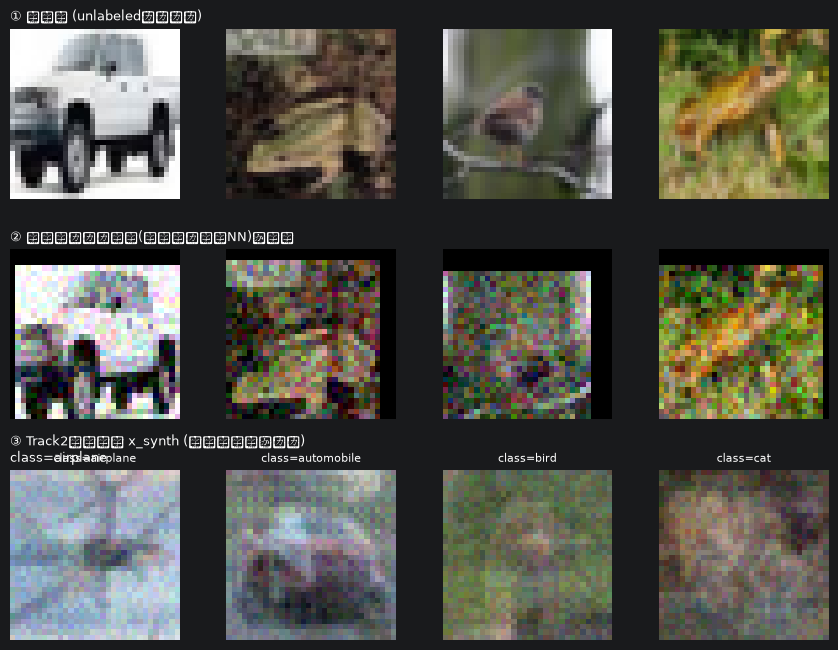

※ ③は未学習(ランダム初期化)モデルでのデモ表示です。実際の学習後の姿を見たい場合は、学習済みbackbone/headに差し替えて同じコードを実行してください。


In [11]:
# ── サンプル画像の可視化: 逆関数データ拡張 と Track2生成画像 ──────────
if cfg.inv_aug_show_samples:
    def _denorm_for_display(x):
        # normalize後のTensorを表示用に[0,1]へ戻す
        mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
        std  = torch.tensor(CIFAR10_STD).view(3,1,1)
        return (x.cpu() * std + mean).clamp(0, 1)

    n_show = 4
    fig, axes = plt.subplots(3, n_show, figsize=(n_show*2.2, 6.6))

    # 1行目: 元画像
    sample_idx = unlabeled_idx[:n_show]
    for j, idx in enumerate(sample_idx):
        img = train_imgs[idx].float() / 255.0
        axes[0, j].imshow(img.permute(1,2,0).numpy()); axes[0, j].axis("off")
        if j == 0: axes[0, j].set_ylabel("元画像", fontsize=10)
    axes[0, 0].set_title("① 元画像 (unlabeledサンプル)", loc="left", fontsize=9)

    # 2行目: 逆関数データ拡張(未学習・凍結NN)で生成した画像
    _inv_aug_demo = InverseFunctionAugment(noise_scale=cfg.inv_aug_noise_scale)
    for j, idx in enumerate(sample_idx):
        v1, _ = _inv_aug_demo(train_imgs[idx])
        axes[1, j].imshow(_denorm_for_display(v1).permute(1,2,0).numpy()); axes[1, j].axis("off")
    axes[1, 0].set_title("② 逆関数データ拡張(未学習・凍結NN)で生成", loc="left", fontsize=9)

    # 3行目: Track2の生成的損失で使われるx_synth(実データ統計を補正して逆関数で画像化)
    # ここでは可視化のためInvertibleNetCIFARを未学習の状態で簡易デモする
    # (実際の学習中は学習が進んだ重みでx_synthが生成される)
    _demo_model = InvertibleNetCIFAR().to(cfg.device)
    _demo_head  = nn.Linear(_demo_model.feat_dim, cfg.n_classes).to(cfg.device)
    _demo_proto = ClassPrototypeBank(cfg.n_classes, _demo_model.feat_dim, cfg.proto_momentum, cfg.device)
    _demo_pixel = PixelPrototypeBank(cfg.n_classes, (3, cfg.img_size, cfg.img_size), cfg.proto_momentum, cfg.device)
    with torch.no_grad():
        _demo_x = torch.stack([eval_aug(train_imgs[i]) for i in labeled_idx]).to(cfg.device)
        _demo_y = torch.stack([train_lbls[i] for i in labeled_idx]).to(cfg.device)
        _demo_z = _demo_model.forward_features(_demo_x)
    _demo_proto.update(_demo_z, _demo_y)
    _demo_pixel.update(_demo_x, _demo_y)
    for j in range(n_show):
        target_class = torch.tensor([j % cfg.n_classes], device=cfg.device)
        with torch.no_grad():
            loss_demo = track2_generative_loss(_demo_model, _demo_head, target_class, _demo_proto, _demo_pixel, cfg)
            # 表示用に x_synth を再計算(track2_generative_loss内部と同じ処理)
            W, b = _demo_head.weight, _demo_head.bias
            W_pinv = torch.linalg.pinv(W)
            anchor = _demo_proto.get(j % cfg.n_classes).unsqueeze(0)
            target_logits = F.one_hot(target_class, cfg.n_classes).float() * cfg.inv_target_logit_scale
            current_logits = anchor @ W.T + b
            feat_target = anchor + (target_logits - current_logits) @ W_pinv.T
            x_synth = _demo_model.invert(feat_target)
        axes[2, j].imshow(_denorm_for_display(x_synth[0]).permute(1,2,0).numpy()); axes[2, j].axis("off")
        axes[2, j].set_title(f"class={cfg.cifar10_classes[j % cfg.n_classes]}", fontsize=8)
    axes[2, 0].set_title(f"③ Track2生成画像 x_synth (未学習時点のデモ)\nclass={cfg.cifar10_classes[0]}", loc="left", fontsize=9)

    plt.tight_layout(); plt.show()
    del _demo_model, _demo_head, _demo_proto, _demo_pixel
    print("※ ③は未学習(ランダム初期化)モデルでのデモ表示です。実際の学習後の姿を見たい場合は、"
          "学習済みbackbone/headに差し替えて同じコードを実行してください。")



In [12]:
# ══════════════════════════════════════════════════════════════
# 比較対象: ResNet-18 / ViT-tiny 用の「学習可能な近似逆写像」(デコーダ)
#
# CNN/ViTのReLU・MaxPool・ストライド畳み込みは真の逆関数を持たないため、
# 手作りのdeconvnet近似ではなく、エンコーダ(既存backbone)に対応する
# 「学習で近似逆写像を獲得するデコーダ」を追加する。InvertibleNetCIFARとの
# 公平な比較のため、同じTrack2損失(画像空間で実データと直接比較)を適用できる
# ようにforward_features()と対になるinvert()メソッドを持たせる。
# ══════════════════════════════════════════════════════════════

class ApproxDecoder(nn.Module):
    """feat_dim次元の特徴量から32×32画像を再構成する学習可能デコーダ。
    ResNet-18(feat_dim=512)・ViT-tiny(feat_dim=192)のどちらにも使える汎用版。"""
    def __init__(self, feat_dim, out_ch=3, base=64):
        super().__init__()
        self.fc = nn.Linear(feat_dim, base * 4 * 4 * 4)
        self.base = base
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1), nn.ReLU(inplace=True),  # 4->8
            nn.ConvTranspose2d(base*2, base,   4, stride=2, padding=1), nn.ReLU(inplace=True),  # 8->16
            nn.ConvTranspose2d(base,   base,   4, stride=2, padding=1), nn.ReLU(inplace=True),  # 16->32
            nn.Conv2d(base, out_ch, 3, padding=1))
    def forward(self, z):
        B = z.size(0)
        x = self.fc(z).view(B, self.base*4, 4, 4)
        return torch.tanh(self.net(x))

def attach_approx_decoder(backbone):
    """既存のResNet18CIFAR/ViTTinyCIFARインスタンスにinvert()メソッドを後付けする。
    デコーダ自体もbackboneのサブモジュールとして登録され、通常の学習ループで一緒に最適化される。"""
    backbone.decoder = ApproxDecoder(backbone.feat_dim)
    backbone.invert = lambda z: backbone.decoder(z)
    return backbone

print("ApproxDecoder(ResNet/ViT用の学習可能な近似逆写像)定義完了")


ApproxDecoder(ResNet/ViT用の学習可能な近似逆写像)定義完了


In [13]:
# ── 線形プローブ ─────────────────────────────────────────────
def linear_probe(backbone, cfg: Config, loader_tr, loader_val):
    # backbone を freeze し、線形分類器のみを学習。
    backbone.eval()
    head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    opt = torch.optim.AdamW(head.parameters(), lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    best_val = 0.; best_state = None
    for ep in range(1, cfg.cls_epochs+1):
        head.train()
        for x, y in loader_tr:
            x, y = x.to(cfg.device), y.to(cfg.device)
            with torch.no_grad(): feat = backbone.forward_features(x)
            loss = F.cross_entropy(head(feat), y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        # val 評価
        head.eval()
        correct = tot = 0
        with torch.no_grad():
            for x, y in loader_val:
                x, y = x.to(cfg.device), y.to(cfg.device)
                feat = backbone.forward_features(x)
                correct += (head(feat).argmax(1) == y).sum().item(); tot += y.size(0)
        val_acc = correct / tot
        if val_acc > best_val:
            best_val = val_acc; best_state = copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    return head, best_val

# ── 教師あり fine-tune (backbone + head 同時学習) ────────────
def supervised_finetune(backbone, cfg: Config, loader_tr, loader_val,
                        freeze_backbone=False, head=None, desc="FT"):
    # backbone(+head)を教師あり学習。head=None なら新規作成。
    backbone = backbone.to(cfg.device)
    if head is None:
        head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    params = list(head.parameters())
    if not freeze_backbone:
        params += list(backbone.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    best_val = 0.; best_bb = None; best_hd = None
    pbar = tqdm(range(1, cfg.cls_epochs+1), desc=desc, leave=False)
    for ep in pbar:
        backbone.train() if not freeze_backbone else backbone.eval()
        head.train()
        for x, y in loader_tr:
            x, y = x.to(cfg.device), y.to(cfg.device)
            loss = F.cross_entropy(head(backbone.forward_features(x)), y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        head.eval(); backbone.eval()
        correct = tot = 0
        with torch.no_grad():
            for x, y in loader_val:
                x, y = x.to(cfg.device), y.to(cfg.device)
                correct += (head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot+=y.size(0)
        val_acc = correct / tot
        if val_acc > best_val:
            best_val = val_acc
            best_bb = copy.deepcopy(backbone.state_dict())
            best_hd = copy.deepcopy(head.state_dict())
        pbar.set_postfix(val_acc=f"{val_acc*100:.1f}%", best=f"{best_val*100:.1f}%")
    backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    return backbone, head, best_val

def evaluate(backbone, head, loader, desc="test", return_probs=False):
    backbone.eval(); head.eval()
    correct = tot = 0
    all_probs = [] if return_probs else None
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(cfg.device), y.to(cfg.device)
            logits = head(backbone.forward_features(x))
            correct += (logits.argmax(1)==y).sum().item(); tot+=y.size(0)
            if return_probs:
                all_probs.append(F.softmax(logits, dim=-1).cpu())
    acc = correct / tot
    print(f"  [{desc}] ★ TEST Accuracy: {acc*100:.2f}%")
    if return_probs:
        return acc, torch.cat(all_probs, dim=0)  # [N_test, n_classes]
    return acc

print("分類器学習関数定義完了")


分類器学習関数定義完了


In [14]:
def pseudo_label_selftrain(backbone, head, cfg: Config,
                           loader_lbl, loader_unl_eval, loader_val, n_epochs=None, desc="PL"):
    # 疑似ラベル自己訓練ループ。
    # 1) unlabeled に対し backbone+head で予測
    # 2) 信頼度 >= threshold のサンプルを擬似ラベルとして labeled に追加
    # 3) combined で学習
    # n_epochs未指定ならcfg.cls_epochsを使うが、boosting弱学習器として呼ぶ場合は
    # cfg.boost_round_epochsのような短いエポック数を明示的に渡すこと。
    n_epochs = n_epochs or cfg.cls_epochs
    backbone = backbone.to(cfg.device); head = head.to(cfg.device)
    best_val = 0.; best_bb = None; best_hd = None

    for rnd in range(cfg.n_self_train_rounds):
        # ── 疑似ラベル生成 ─────────────────────────────────
        backbone.eval(); head.eval()
        pseudo_imgs, pseudo_lbls = [], []
        with torch.no_grad():
            for x in loader_unl_eval:
                x = x.to(cfg.device)
                prob = F.softmax(head(backbone.forward_features(x)), dim=-1)
                conf, pred = prob.max(dim=-1)
                mask = conf >= cfg.pseudo_threshold
                if mask.any():
                    pseudo_imgs.append(x[mask].cpu()); pseudo_lbls.append(pred[mask].cpu())
        n_pseudo = sum(len(p) for p in pseudo_lbls)
        print(f"  [{desc} rnd {rnd+1}/{cfg.n_self_train_rounds}] 疑似ラベル採用: {n_pseudo}/{len(loader_unl_eval.dataset)}")

        # ── combined Dataset ───────────────────────────────
        if n_pseudo > 0:
            all_imgs_pseudo = torch.cat(pseudo_imgs)
            all_lbls_pseudo = torch.cat(pseudo_lbls)
            # labeled とマージ: eval_aug 適用済みなので直接使う
            # labeled 側は loader_lbl から全取得
            lbl_imgs, lbl_ys = zip(*[(x,y) for x,y in loader_lbl])
            lbl_imgs = torch.cat(lbl_imgs); lbl_ys = torch.cat(lbl_ys)
            comb_imgs = torch.cat([lbl_imgs, all_imgs_pseudo])
            comb_ys   = torch.cat([lbl_ys,   all_lbls_pseudo])

            class TensorDataset(Dataset):
                def __init__(self, imgs, lbls, aug=None):
                    self.imgs=imgs; self.lbls=lbls; self.aug=aug
                def __len__(self): return len(self.imgs)
                def __getitem__(self, i):
                    x=self.imgs[i]
                    if self.aug: x=self.aug(x)
                    return x, self.lbls[i]

            combined_ds = TensorDataset(comb_imgs, comb_ys)
            loader_comb = DataLoader(combined_ds, batch_size=cfg.cls_batch, shuffle=True, num_workers=0)
        else:
            loader_comb = loader_lbl  # 疑似ラベルなし

        # ── 学習 ──────────────────────────────────────────
        params = list(backbone.parameters()) + list(head.parameters())
        opt = torch.optim.AdamW(params, lr=cfg.cls_lr*0.5, weight_decay=cfg.cls_wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
        for ep in tqdm(range(1, n_epochs+1), desc=f"{desc}-rnd{rnd+1}", leave=False):
            backbone.train(); head.train()
            for x, y in loader_comb:
                x, y = x.to(cfg.device), y.to(cfg.device)
                loss = F.cross_entropy(head(backbone.forward_features(x)), y)
                opt.zero_grad(); loss.backward(); opt.step()
            sched.step()
            # 毎エポック評価してベストモデルを選ぶ(以前はep%100==0だったため
            # n_epochsが短いboosting弱学習器では一度も評価されないバグがあった)
            backbone.eval(); head.eval()
            correct=tot=0
            with torch.no_grad():
                for x,y in loader_val:
                    x,y=x.to(cfg.device),y.to(cfg.device)
                    correct+=(head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot+=y.size(0)
            val_acc = correct/tot
            if val_acc > best_val:
                best_val = val_acc
                best_bb = copy.deepcopy(backbone.state_dict())
                best_hd = copy.deepcopy(head.state_dict())

    if best_bb: backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    return backbone, head, best_val

print("疑似ラベル自己訓練関数定義完了")


疑似ラベル自己訓練関数定義完了


In [15]:
# ══════════════════════════════════════════════════════════════
# SAMME Boosting + 手法間アンサンブル
#
# 設計変更(前バージョンのCV-foldバギングから変更):
#   - 手法内: labeled(train_only_idx, 40枚)全体を使い、SAMMEブースティングで
#     複数の「弱学習器」(エポック数を絞ったモデル)を順次学習。誤りサンプルの
#     重みを上げながら次ラウンドを学習し、alpha(信頼度)重み付き平均でtest確率を統合。
#   - 手法間: supervised-only と simclr+semisup、それぞれのboosting結果(test確率)を
#     val_acc平均による自信度重み付き平均で統合(前研究CIFAR-100のCLIP+ConvNeXt統合と同じ設計)。
# ══════════════════════════════════════════════════════════════

import numpy as np

def mixup_cutmix(x, y, w, cfg):
    """Mixup/CutMixを1バッチに適用する。戻り値: (mixed_x, y_a, y_b, w_a, w_b, lam)。
    損失は lam*CE(logits,y_a,w_a) + (1-lam)*CE(logits,y_b,w_b) として計算する。"""
    B = x.size(0)
    perm = torch.randperm(B, device=x.device)
    lam = float(np.random.beta(cfg.mixup_alpha, cfg.mixup_alpha)) if cfg.mixup_alpha > 0 else 1.0
    y_a, y_b = y, y[perm]
    w_a, w_b = w, w[perm]
    if np.random.rand() < cfg.cutmix_prob:
        # CutMix: 矩形領域をもう片方の画像で置き換える
        H, W_ = x.shape[2], x.shape[3]
        cut_rat = np.sqrt(1. - lam)
        cut_h, cut_w = int(H * cut_rat), int(W_ * cut_rat)
        cy, cx = np.random.randint(H), np.random.randint(W_)
        y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
        x1, x2 = np.clip(cx - cut_w // 2, 0, W_), np.clip(cx + cut_w // 2, 0, W_)
        x_mixed = x.clone()
        x_mixed[:, :, y1:y2, x1:x2] = x[perm][:, :, y1:y2, x1:x2]
        lam = 1 - ((x2 - x1) * (y2 - y1) / (H * W_))   # 実際に置き換わった面積比で補正
    else:
        # Mixup: 画素の線形補間
        x_mixed = lam * x + (1 - lam) * x[perm]
    return x_mixed, y_a, y_b, w_a, w_b, lam

def mixup_cutmix_loss(logits, y_a, y_b, w_a, w_b, lam):
    loss_a = (F.cross_entropy(logits, y_a, reduction="none") * w_a).mean()
    loss_b = (F.cross_entropy(logits, y_b, reduction="none") * w_b).mean()
    return lam * loss_a + (1 - lam) * loss_b

print("Mixup/CutMix関数定義完了")


Mixup/CutMix関数定義完了


In [16]:
# ══════════════════════════════════════════════════════════════
# キャッシュユーティリティ
# SimCLR事前学習・boosting結果をディスク(cfg.cache_dir)に保存し、
# 同じ設定(n_unlabeled, n_boost_rounds, use_mixup_cutmix等)での再実行時はスキップする。
# キャッシュキーには関連するcfgパラメータを含めること(呼び出し側の責任)。
# ══════════════════════════════════════════════════════════════
def _cache_path(key):
    safe_key = "".join(c if c.isalnum() or c in "_-." else "_" for c in key)
    return os.path.join(cfg.cache_dir, f"{safe_key}.pt")

def cached_torch(key, compute_fn):
    path = _cache_path(key)
    if cfg.use_disk_cache and os.path.exists(path):
        print(f"  [cache hit] {key}")
        return torch.load(path, map_location="cpu", weights_only=False)
    result = compute_fn()
    if cfg.use_disk_cache:
        os.makedirs(cfg.cache_dir, exist_ok=True)
        torch.save(result, path)
        print(f"  [cache saved] {key}")
    return result

print("キャッシュユーティリティ定義完了")


キャッシュユーティリティ定義完了


In [17]:
class WeightedCIFAR10Set(Dataset):
    """SAMME boosting用: サンプル重みも一緒に返すDataset"""
    def __init__(self, imgs, lbls, idx, weights, transform=None):
        self.imgs = imgs[idx]; self.lbls = lbls[idx]
        self.weights = torch.as_tensor(weights, dtype=torch.float32)
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i]
        if self.transform: x = self.transform(x)
        return x, self.lbls[i], self.weights[i]

def make_weighted_loader(idx, weights, transform, batch):
    ds = WeightedCIFAR10Set(train_imgs, train_lbls, idx, weights, transform)
    return DataLoader(ds, batch_size=batch, shuffle=True, num_workers=0)

def weighted_finetune(backbone, cfg, loader_w, loader_val, head=None,
                       freeze_backbone=False, n_epochs=None, desc="WFT"):
    """SAMME用: サンプル重み付きCEで学習する弱学習器トレーナー。
    n_epochs未指定ならcfg.boost_round_epochsを使う(弱学習器化のため意図的に短い)。"""
    n_epochs = n_epochs or cfg.boost_round_epochs
    backbone = backbone.to(cfg.device)
    if head is None:
        head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    params = list(head.parameters()) + ([] if freeze_backbone else list(backbone.parameters()))
    opt = torch.optim.AdamW(params, lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, max(n_epochs, 1))
    best_val = 0.; best_bb = None; best_hd = None
    pbar = tqdm(range(1, n_epochs + 1), desc=desc, leave=False)
    for ep in pbar:
        backbone.train() if not freeze_backbone else backbone.eval()
        head.train()
        for x, y, w in loader_w:
            x, y, w = x.to(cfg.device), y.to(cfg.device), w.to(cfg.device)
            if cfg.use_mixup_cutmix:
                x, y_a, y_b, w_a, w_b, lam = mixup_cutmix(x, y, w, cfg)
                logits = head(backbone.forward_features(x))
                loss = mixup_cutmix_loss(logits, y_a, y_b, w_a, w_b, lam)
            else:
                logits = head(backbone.forward_features(x))
                loss = (F.cross_entropy(logits, y, reduction="none") * w).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        backbone.eval(); head.eval()
        correct = tot = 0
        with torch.no_grad():
            for x, y in loader_val:
                x, y = x.to(cfg.device), y.to(cfg.device)
                correct += (head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot += y.size(0)
        val_acc = correct / tot
        if val_acc >= best_val:
            best_val = val_acc
            best_bb = copy.deepcopy(backbone.state_dict()); best_hd = copy.deepcopy(head.state_dict())
        pbar.set_postfix(val_acc=f"{val_acc*100:.1f}%", best=f"{best_val*100:.1f}%")
    if best_bb: backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    return backbone, head, best_val

def samme_boost(arch_cls, cfg, method, train_idx, loader_val, loader_unl_for_pl,
                 loader_lbl_for_pl, simclr_state=None, use_track2=False, cache_key=None, desc=""):
    """SAMME多クラスboosting。【重要】テストセットには一切触れない(train/valのみ使用)。
    各ラウンドの学習済みモデル(state_dict)とalpha(信頼度)を保存して返す。
    テストセットでの評価は、全ラウンドの学習が完了したあとに呼び出し側が別途行う。
    戻り値: (round_states: [(bb_state_dict, head_state_dict), ...], alphas: [float], mean_val_acc)
    cache_keyを指定すると、同じ設定での再実行時はディスクキャッシュから読み込みスキップする。"""
    def _compute():
        n = len(train_idx)
        weights = np.ones(n) / n
        K = cfg.n_classes
        train_lbls_arr = np.array([train_lbls[i].item() for i in train_idx])
        alphas, round_states, val_accs = [], [], []

        for m in tqdm(range(cfg.n_boost_rounds), desc=f"{desc} (boosting rounds)"):
            loader_w = make_weighted_loader(train_idx, weights, train_aug, cfg.cls_batch)
            bb = arch_cls().to(cfg.device)

            if method == "supervised-only":
                bb, head, val_acc = weighted_finetune(bb, cfg, loader_w, loader_val, desc=f"{desc}-b{m}")
            else:  # "simclr+semisup"
                bb.load_state_dict(copy.deepcopy(simclr_state))
                _, head, _ = weighted_finetune(bb, cfg, loader_w, loader_val, freeze_backbone=True, desc=f"{desc}-probe{m}")
                if use_track2:
                    # NN逆関数伝播対応バックボーン(InvertibleNetCIFAR / ApproxDecoder付与済み)
                    # → Track1(識別的CE)+Track2(生成的損失)の二経路で学習
                    bb, head, val_acc = weighted_finetune_with_track2(bb, cfg, loader_w, loader_val, head=head, desc=f"{desc}-ft{m}")
                else:
                    bb, head, val_acc = weighted_finetune(bb, cfg, loader_w, loader_val, head=head,
                                                           freeze_backbone=False, desc=f"{desc}-ft{m}")
                # 疑似ラベル自己訓練もboosting弱学習器の性質を壊さないようboost_round_epochsで短く
                bb, head, val_acc = pseudo_label_selftrain(
                    bb, head, cfg, loader_lbl_for_pl, loader_unl_for_pl, loader_val,
                    n_epochs=cfg.boost_round_epochs, desc=f"{desc}-pl{m}")

            # ── train上の重み付き誤り率からSAMME alphaを計算(テストセットは不使用) ──
            bb.eval(); head.eval()
            preds = []
            with torch.no_grad():
                for i0 in range(0, len(train_idx), 64):
                    batch_idx = train_idx[i0:i0+64]
                    x = torch.stack([eval_aug(train_imgs[i]) for i in batch_idx]).to(cfg.device)
                    preds.append(head(bb.forward_features(x)).argmax(1).cpu().numpy())
            preds = np.concatenate(preds)
            incorrect = (preds != train_lbls_arr).astype(float)
            err = np.clip(np.sum(weights * incorrect) / np.sum(weights), 1e-6, 1 - 1e-6)
            alpha = np.log((1 - err) / err) + np.log(K - 1)   # SAMME(多クラス)
            weights = weights * np.exp(alpha * incorrect)
            weights = weights / weights.sum()

            alphas.append(max(alpha, 1e-6))  # 負のalpha(ランダム以下)は保険で下限クリップ
            round_states.append((copy.deepcopy(bb.state_dict()), copy.deepcopy(head.state_dict())))
            val_accs.append(val_acc)
            print(f"  [{desc} round {m+1}/{cfg.n_boost_rounds}] train_err={err:.3f} alpha={alpha:.3f} val_acc={val_acc*100:.1f}%")

        return round_states, alphas, float(np.mean(val_accs))

    if cache_key:
        return cached_torch(cache_key, _compute)
    return _compute()

@torch.no_grad()
def apply_boosted_on_test(arch_cls, round_states, alphas, loader_test, cfg):
    """学習済みのboostingラウンド群を、テストセットに対して一度だけ適用する。
    (学習中は一切テストセットに触れず、ここで初めて・一度だけ使う)"""
    alphas_t = torch.tensor(alphas, dtype=torch.float32)
    alphas_t = alphas_t / alphas_t.sum()
    probs_sum = None
    for (bb_state, hd_state), a in tqdm(list(zip(round_states, alphas_t)), desc="apply boosted models on test"):
        bb = arch_cls().to(cfg.device); bb.load_state_dict(bb_state)
        head = nn.Linear(bb.feat_dim, cfg.n_classes).to(cfg.device); head.load_state_dict(hd_state)
        bb.eval(); head.eval()
        _, probs = evaluate(bb, head, loader_test, desc="(final test eval)", return_probs=True)
        probs_sum = a * probs if probs_sum is None else probs_sum + a * probs
    return probs_sum

print("SAMME boosting (テストセット不使用・キャッシュ対応版) 定義完了")


SAMME boosting (テストセット不使用・キャッシュ対応版) 定義完了


In [18]:
def weighted_finetune_with_track2(backbone, cfg, loader_w, loader_val, head=None,
                                   n_epochs=None, desc="WFT-T2"):
    """weighted_finetuneのNN逆関数伝播版。Track1(重み付きCE)にTrack2(生成的損失)を
    加えて学習する。backboneは.invert()を持つ必要がある(InvertibleNetCIFAR / ApproxDecoder付与済み)。"""
    n_epochs = n_epochs or cfg.boost_round_epochs
    backbone = backbone.to(cfg.device)
    if head is None:
        head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    proto_bank  = ClassPrototypeBank(cfg.n_classes, backbone.feat_dim, cfg.proto_momentum, cfg.device)
    pixel_bank  = PixelPrototypeBank(cfg.n_classes, (3, cfg.img_size, cfg.img_size), cfg.proto_momentum, cfg.device)
    params = list(head.parameters()) + list(backbone.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, max(n_epochs, 1))
    best_val = 0.; best_bb = None; best_hd = None
    epoch_loss1_hist, epoch_loss2_hist = [], []   # 診断用: Track1/Track2の大きさを記録

    pbar = tqdm(range(1, n_epochs + 1), desc=desc, leave=False)
    for ep in pbar:
        backbone.train(); head.train()
        ep_loss1_sum = ep_loss2_sum = ep_loss2_n = 0.0
        for x, y, w in loader_w:
            x, y, w = x.to(cfg.device), y.to(cfg.device), w.to(cfg.device)

            # ── プロトタイプ統計の更新は「混ぜていない」元画像のzで行う ──
            # (Mixup/CutMixで混ぜたラベルを使うとクラス統計が汚染されるため)
            with torch.no_grad():
                z_clean = backbone.forward_features(x)
            proto_bank.update(z_clean, y)
            pixel_bank.update(x, y)

            # ── Track1損失: Mixup/CutMixを使う場合はここでのみ適用 ──
            if cfg.use_mixup_cutmix:
                x_mix, y_a, y_b, w_a, w_b, lam = mixup_cutmix(x, y, w, cfg)
                logits = head(backbone.forward_features(x_mix))
                loss1 = mixup_cutmix_loss(logits, y_a, y_b, w_a, w_b, lam)
            else:
                logits = head(backbone.forward_features(x))
                loss1 = (F.cross_entropy(logits, y, reduction="none") * w).mean()

            loss = loss1
            ep_loss1_sum += loss1.item()
            if proto_bank.ready(y.unique().tolist()) and pixel_bank.ready(y.unique().tolist()):
                target_classes = y[torch.randperm(y.size(0))]                   # ランダムな目標クラス(バッチ内から流用)
                loss2 = track2_generative_loss(backbone, head, target_classes, proto_bank, pixel_bank, cfg)
                loss = loss1 + cfg.inv_track2_weight * loss2                    # Track2
                ep_loss2_sum += loss2.item(); ep_loss2_n += 1

            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        epoch_loss1_hist.append(ep_loss1_sum / max(len(loader_w), 1))
        epoch_loss2_hist.append(ep_loss2_sum / max(ep_loss2_n, 1) if ep_loss2_n > 0 else 0.0)

        backbone.eval(); head.eval()
        correct = tot = 0
        with torch.no_grad():
            for xv, yv in loader_val:
                xv, yv = xv.to(cfg.device), yv.to(cfg.device)
                correct += (head(backbone.forward_features(xv)).argmax(1)==yv).sum().item(); tot += yv.size(0)
        val_acc = correct / tot
        if val_acc >= best_val:
            best_val = val_acc
            best_bb = copy.deepcopy(backbone.state_dict()); best_hd = copy.deepcopy(head.state_dict())
        pbar.set_postfix(loss1=f"{epoch_loss1_hist[-1]:.3f}",
                          loss2=f"{epoch_loss2_hist[-1]:.3f}",
                          weighted_loss2=f"{cfg.inv_track2_weight*epoch_loss2_hist[-1]:.3f}",
                          val_acc=f"{val_acc*100:.1f}%")
    if best_bb: backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    # ── 診断ログ: Track1/Track2の損失の大きさを比較表示 ──────
    # (Track2がTrack1に対してどれくらいの規模で効いているかを確認するため)
    mean_loss1 = float(np.mean(epoch_loss1_hist)) if epoch_loss1_hist else 0.0
    mean_loss2 = float(np.mean([l for l in epoch_loss2_hist if l > 0])) if any(l > 0 for l in epoch_loss2_hist) else 0.0
    weighted_loss2 = cfg.inv_track2_weight * mean_loss2
    ratio = weighted_loss2 / mean_loss1 if mean_loss1 > 0 else 0.0
    print(f"    [{desc}] 診断: mean(loss1)={mean_loss1:.4f}  mean(loss2)={mean_loss2:.4f}"
          f"  weighted_loss2(={cfg.inv_track2_weight}*loss2)={weighted_loss2:.4f}"
          f"  → loss2/loss1比={ratio:.2%} (この比率が極端に小さいとTrack2の寄与が薄い可能性)")
    return backbone, head, best_val

print("weighted_finetune_with_track2 (二経路勾配降下) 定義完了")


weighted_finetune_with_track2 (二経路勾配降下) 定義完了


In [19]:
# ══════════════════════════════════════════════════════════════
# メイン実験(再設計版):
#
#   比較A(ベースライン): labeledのみで素朴に学習したResNet-18 / ViT-tiny
#                        (boosting・SimCLR・Mixup等は使わない単純な教師あり学習)
#   比較B(最終提案システム): SimCLR自己教師あり事前学習・疑似ラベル自己訓練・
#                        Mixup/CutMix・網膜模倣・NN逆関数伝播などを組み込んだ
#                        複数バックボーン(ResNet-18/ViT-tiny/+Track2版/InvertibleNet)
#                        をそれぞれSAMME boostingし、バックボーン間でさらに
#                        自信度重み付きアンサンブルした「単一の最終成果物」
#
#   【テストセットの扱い】train/valのみで全学習(boosting・モデル選択含む)を完了させ、
#   test 10,000件は全学習が終わったあとに一度だけ使う(比較Aも比較Bも同様)。
#
#   【削除】逆関数伝播(Track2)はsupervised-onlyには使わない(意味がないため)。
#   Track2対応バックボーン(+Track2, InvertibleNet)は"simclr+semisup"のみ計算する。
#
#   【キャッシュ】SimCLR事前学習・boosting結果はcfg.cache_dirにキャッシュされ、
#   同じ設定での再実行はスキップされる(cfg.use_disk_cache=Falseで無効化可能)。
# ══════════════════════════════════════════════════════════════

os.makedirs(cfg.cache_dir, exist_ok=True)

# ── 比較A: 素朴なベースライン(labeledのみ、boosting等一切なし) ─────
print("="*60); print("  比較A: ベースライン(labeledのみで素朴に学習)"); print("="*60)

BASELINES = {}
for arch_name, arch_cls in [("ResNet-18", ResNet18CIFAR), ("ViT-tiny", ViTTinyCIFAR)]:
    cache_key = f"baseline_{arch_name}_nlabeled{cfg.n_labeled}_seed{cfg.seed}_mixup{cfg.use_mixup_cutmix}_opp{cfg.use_opponent_color}"
    def _compute_baseline(arch_cls=arch_cls, arch_name=arch_name):
        set_seed(cfg.seed)
        bb = arch_cls().to(cfg.device)
        bb, head, val_acc = supervised_finetune(bb, cfg, loader_lbl, loader_val, desc=f"{arch_name}-baseline")
        return copy.deepcopy(bb.state_dict()), copy.deepcopy(head.state_dict()), val_acc
    bb_state, hd_state, val_acc = cached_torch(cache_key, _compute_baseline)
    BASELINES[arch_name] = {"arch_cls": arch_cls, "bb_state": bb_state, "hd_state": hd_state, "val_acc": val_acc}
    print(f"  [{arch_name}] baseline学習完了 (val_acc={val_acc*100:.2f}%、testはまだ使っていない)")

# ── 比較B: 最終提案システムの各構成要素をboosting学習(test未使用) ──
print("\n" + "="*60); print("  比較B: 最終提案システムの構成要素を学習(SimCLR+boosting)"); print("="*60)

# (arch_name, arch_cls, use_track2)
PROPOSED_COMPONENTS = [
    ("ResNet-18",         ResNet18CIFAR,                                    False),
    ("ViT-tiny",          ViTTinyCIFAR,                                     False),
    ("ResNet-18+Track2",  lambda: attach_approx_decoder(ResNet18CIFAR()),   True),
    ("ViT-tiny+Track2",   lambda: attach_approx_decoder(ViTTinyCIFAR()),    True),
    ("InvertibleNet",     InvertibleNetCIFAR,                               True),
]

component_round_states = {}   # {arch_name: (arch_cls, round_states)}
component_alphas = {}
component_val = {}

for arch_name, arch_cls, use_track2 in PROPOSED_COMPONENTS:
    print(f"\n--- [{arch_name}] (n_unlabeled={cfg.n_unlabeled}, boost_rounds={cfg.n_boost_rounds}) ---")

    simclr_key = f"simclr_{arch_name}_nunlabeled{cfg.n_unlabeled}_epochs{cfg.simclr_epochs}_invaug{cfg.use_inverse_augment}_seed{cfg.seed}"
    def _compute_simclr(arch_cls=arch_cls, arch_name=arch_name):
        set_seed(cfg.seed)
        bb = arch_cls().to(cfg.device)
        bb, _ = pretrain_simclr(bb, cfg, loader_simclr_active, desc=f"{arch_name}-SimCLR")
        return copy.deepcopy(bb.state_dict())
    simclr_state = cached_torch(simclr_key, _compute_simclr)

    boost_key = (f"boost_{arch_name}_nunlabeled{cfg.n_unlabeled}_nlabeled{cfg.n_labeled}"
                 f"_rounds{cfg.n_boost_rounds}_epochs{cfg.boost_round_epochs}"
                 f"_mixup{cfg.use_mixup_cutmix}_opp{cfg.use_opponent_color}"
                 f"_invaug{cfg.use_inverse_augment}_seed{cfg.seed}")   # バグ修正: invaugが抜けていた(simclr_stateの変化がキャッシュに反映されない不具合)
    set_seed(cfg.seed)
    round_states, alphas, mean_val = samme_boost(
        arch_cls, cfg, "simclr+semisup", train_only_idx, loader_val,
        loader_unl, loader_lbl, simclr_state=simclr_state, use_track2=use_track2,
        cache_key=boost_key, desc=arch_name)

    component_round_states[arch_name] = (arch_cls, round_states)
    component_alphas[arch_name] = alphas
    component_val[arch_name] = mean_val
    print(f"  >>> [{arch_name}] 学習完了 mean_val_acc={mean_val*100:.2f}% (testはまだ使っていない)")

print("\n" + "="*60)
print("  全学習完了。ここまでtest 10,000件は一切使用していません。")
print("="*60)


  比較A: ベースライン(labeledのみで素朴に学習)
  [cache hit] baseline_ResNet-18_nlabeled50_seed42_mixupTrue_oppFalse
  [ResNet-18] baseline学習完了 (val_acc=40.00%、testはまだ使っていない)
  [cache hit] baseline_ViT-tiny_nlabeled50_seed42_mixupTrue_oppFalse
  [ViT-tiny] baseline学習完了 (val_acc=40.00%、testはまだ使っていない)

  比較B: 最終提案システムの構成要素を学習(SimCLR+boosting)

--- [ResNet-18] (n_unlabeled=100, boost_rounds=5) ---
  [cache hit] simclr_ResNet-18_nunlabeled100_epochs200_invaugTrue_seed42


ResNet-18 (boosting rounds):   0%|          | 0/5 [00:00<?, ?it/s]

ResNet-18-probe0:   0%|          | 0/20 [00:00<?, ?it/s]

ResNet-18-ft0:   0%|          | 0/20 [00:00<?, ?it/s]

  [ResNet-18-pl0 rnd 1/3] 疑似ラベル採用: 3/100


...

  [InvertibleNet-pl4 rnd 2/3] 疑似ラベル採用: 9/100


InvertibleNet-pl4-rnd2:   0%|          | 0/20 [00:00<?, ?it/s]

  [InvertibleNet-pl4 rnd 3/3] 疑似ラベル採用: 31/100


InvertibleNet-pl4-rnd3:   0%|          | 0/20 [00:00<?, ?it/s]

  [InvertibleNet round 5/5] train_err=0.212 alpha=3.509 val_acc=50.0%
  [cache saved] boost_InvertibleNet_nunlabeled100_nlabeled50_rounds5_epochs20_mixupTrue_oppFalse_invaugTrue_seed42
  >>> [InvertibleNet] 学習完了 mean_val_acc=42.00% (testはまだ使っていない)

  全学習完了。ここまでtest 10,000件は一切使用していません。


In [20]:
# ══════════════════════════════════════════════════════════════
# 最終評価: テストセットをここで初めて・一度だけ使用する
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60); print("  最終評価(テストセット初使用)"); print("="*60)

# ── 比較A: ベースラインをtestで一度だけ評価 ─────────────────
baseline_test_acc = {}
for arch_name, b in BASELINES.items():
    bb = b["arch_cls"]().to(cfg.device); bb.load_state_dict(b["bb_state"])
    head = nn.Linear(bb.feat_dim, cfg.n_classes).to(cfg.device); head.load_state_dict(b["hd_state"])
    acc = evaluate(bb, head, loader_test, desc=f"Baseline {arch_name}")
    baseline_test_acc[arch_name] = acc

# ── 比較B: 各構成要素をtestで評価しつつ、バックボーン間アンサンブルも構築 ──
component_test_acc = {}
total_val = sum(component_val.values())
final_probs = None
for arch_name, (arch_cls, round_states) in component_round_states.items():
    alphas = component_alphas[arch_name]
    probs = apply_boosted_on_test(arch_cls, round_states, alphas, loader_test, cfg)
    acc = (probs.argmax(-1) == test_lbls).float().mean().item()
    component_test_acc[arch_name] = acc
    weight = component_val[arch_name] / total_val
    final_probs = weight * probs if final_probs is None else final_probs + weight * probs
    print(f"  [{arch_name}] boosted test_acc={acc*100:.2f}%  (最終アンサンブル重み={weight:.3f})")

final_acc = (final_probs.argmax(-1) == test_lbls).float().mean().item()

RESULTS = {
    "baseline_test_acc": baseline_test_acc,
    "component_test_acc": component_test_acc,
    "component_val_acc": component_val,
    "final_proposed_system_acc": final_acc,
}

print("\n" + "="*60)
print("  完了")
print("="*60)



  最終評価(テストセット初使用)
  [Baseline ResNet-18] ★ TEST Accuracy: 21.50%
  [Baseline ViT-tiny] ★ TEST Accuracy: 16.42%


apply boosted models on test:   0%|          | 0/5 [00:00<?, ?it/s]

  [(final test eval)] ★ TEST Accuracy: 20.90%
  [(final test eval)] ★ TEST Accuracy: 21.38%
  [(final test eval)] ★ TEST Accuracy: 11.65%
  [(final test eval)] ★ TEST Accuracy: 19.27%
  [(final test eval)] ★ TEST Accuracy: 22.03%
  [ResNet-18] boosted test_acc=23.24%  (最終アンサンブル重み=0.225)


apply boosted models on test:   0%|          | 0/5 [00:00<?, ?it/s]

  [(final test eval)] ★ TEST Accuracy: 21.52%
  [(final test eval)] ★ TEST Accuracy: 21.16%
  [(final test eval)] ★ TEST Accuracy: 21.49%
  [(final test eval)] ★ TEST Accuracy: 17.18%
  [(final test eval)] ★ TEST Accuracy: 21.41%
  [ViT-tiny] boosted test_acc=22.77%  (最終アンサンブル重み=0.198)


...

  [(final test eval)] ★ TEST Accuracy: 21.07%
  [(final test eval)] ★ TEST Accuracy: 19.19%
  [(final test eval)] ★ TEST Accuracy: 18.30%
  [(final test eval)] ★ TEST Accuracy: 16.51%
  [(final test eval)] ★ TEST Accuracy: 17.63%
  [ResNet-18+Track2] boosted test_acc=20.86%  (最終アンサンブル重み=0.216)


apply boosted models on test:   0%|          | 0/5 [00:00<?, ?it/s]

  [(final test eval)] ★ TEST Accuracy: 22.65%
  [(final test eval)] ★ TEST Accuracy: 21.25%
  [(final test eval)] ★ TEST Accuracy: 22.40%
  [(final test eval)] ★ TEST Accuracy: 21.62%
  [(final test eval)] ★ TEST Accuracy: 20.30%
  [ViT-tiny+Track2] boosted test_acc=22.95%  (最終アンサンブル重み=0.171)


apply boosted models on test:   0%|          | 0/5 [00:00<?, ?it/s]

  [(final test eval)] ★ TEST Accuracy: 19.98%
  [(final test eval)] ★ TEST Accuracy: 18.04%
  [(final test eval)] ★ TEST Accuracy: 21.02%
  [(final test eval)] ★ TEST Accuracy: 15.17%
  [(final test eval)] ★ TEST Accuracy: 22.15%
  [InvertibleNet] boosted test_acc=21.94%  (最終アンサンブル重み=0.189)

  完了


In [21]:
print("\n" + "="*60)
print(f"  最終結果まとめ  (n_unlabeled={cfg.n_unlabeled}, boost_rounds={cfg.n_boost_rounds})")
print("="*60)
print(f"  [参考値・比較しない] CLIP zero-shot: 92.93%")
print()
print("  ■ 比較A: ベースライン(labeledのみ、素朴な教師あり学習)")
for arch_name, acc in RESULTS["baseline_test_acc"].items():
    print(f"      {arch_name:20s}: {acc*100:.2f}%")
print()
print("  ■ 比較B: 最終提案システムの内訳(各構成要素の単体性能)")
for arch_name, acc in RESULTS["component_test_acc"].items():
    print(f"      {arch_name:20s}: {acc*100:.2f}%  (アンサンブル重み={RESULTS['component_val_acc'][arch_name]/sum(RESULTS['component_val_acc'].values()):.3f})")
print()
print(f"  🎯 最終提案システム(全バックボーン・全手法統合アンサンブル): {RESULTS['final_proposed_system_acc']*100:.2f}%")
print()
best_baseline = max(RESULTS["baseline_test_acc"].values())
diff = RESULTS["final_proposed_system_acc"] - best_baseline
print(f"  最良ベースラインとの差: {diff*100:+.2f}pt")
print()
print("  ※ unlabeled を 100 / 500 / 1000 に変えて cfg.n_unlabeled を書き換え再実行してください")
print("  ※ 同じ設定なら再実行時はキャッシュがヒットしスキップされます(cfg.use_disk_cache=Falseで無効化可能)")



  最終結果まとめ  (n_unlabeled=100, boost_rounds=5)
  [参考値・比較しない] CLIP zero-shot: 92.93%

  ■ 比較A: ベースライン(labeledのみ、素朴な教師あり学習)
      ResNet-18           : 21.50%
      ViT-tiny            : 16.42%

  ■ 比較B: 最終提案システムの内訳(各構成要素の単体性能)
      ResNet-18           : 23.24%  (アンサンブル重み=0.225)
      ViT-tiny            : 22.77%  (アンサンブル重み=0.198)
      ResNet-18+Track2    : 20.86%  (アンサンブル重み=0.216)
      ViT-tiny+Track2     : 22.95%  (アンサンブル重み=0.171)
      InvertibleNet       : 21.94%  (アンサンブル重み=0.189)

  🎯 最終提案システム(全バックボーン・全手法統合アンサンブル): 24.92%

  最良ベースラインとの差: +3.42pt

  ※ unlabeled を 100 / 500 / 1000 に変えて cfg.n_unlabeled を書き換え再実行してください
  ※ 同じ設定なら再実行時はキャッシュがヒットしスキップされます(cfg.use_disk_cache=Falseで無効化可能)


## 次のステップ

1. `cfg.n_unlabeled` を 100 → 500 → 1000 に変えて Cell 9〜10 を再実行し、結果を比較する
2. 結果を Notion の引き継ぎページに記録する
3. unlabeled 量と精度の関係を可視化する

## バージョン履歴

| バージョン | 内容 |
|---|---|
| v1 (このノートブック) | scratch ResNet-18 / ViT-tiny + SimCLR + 疑似ラベル、n_unlabeled=100/500/1000 比較 |
